## 파이프라인 구축 (1차)

### Step 1. Roboflow API로 데이터셋 다운로드

In [2]:
# 1. 설치
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 85.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [ ]:
# 2. 다운로드
from roboflow import Roboflow

rf = Roboflow(api_key="vgvnQD3ktPGMXOXsiCG7")  # Roboflow 계정 API 키 입력
project = rf.workspace("s-workspace-6sd3n").project("noongil-barrierfree-ai")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to NoonGil-BarrierFree-AI-1 in yolov8:: 100%|██████████| 777/777 [00:00<00:00, 8910.66it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
print(dataset.location)

/content/NoonGil-BarrierFree-AI-1


### Step 2. data.yaml 경로 확인

In [ ]:
import os, shutil, random

base = "/content/NoonGil-BarrierFree-AI-1"
train_img = f"{base}/train/images"
train_lbl = f"{base}/train/labels"
val_img   = f"{base}/valid/images"
val_lbl   = f"{base}/valid/labels"
test_img  = f"{base}/test/images"
test_lbl  = f"{base}/test/labels"

os.makedirs(val_img, exist_ok=True)
os.makedirs(val_lbl, exist_ok=True)
os.makedirs(test_img, exist_ok=True)
os.makedirs(test_lbl, exist_ok=True)

# 전체 이미지 목록
imgs = [f for f in os.listdir(train_img) if f.endswith(('.jpg','.png'))]
random.seed(42)
random.shuffle(imgs)

# 7:2:1 분할
n = len(imgs)
val_imgs  = imgs[int(n*0.7):int(n*0.9)]
test_imgs = imgs[int(n*0.9):]

def move_split(file_list, src_img, src_lbl, dst_img, dst_lbl):
    for fname in file_list:
        shutil.move(f"{src_img}/{fname}", f"{dst_img}/{fname}")
        lbl = fname.rsplit('.', 1)[0] + '.txt'
        if os.path.exists(f"{src_lbl}/{lbl}"):
            shutil.move(f"{src_lbl}/{lbl}", f"{dst_lbl}/{lbl}")

move_split(val_imgs,  train_img, train_lbl, val_img, val_lbl)
move_split(test_imgs, train_img, train_lbl, test_img, test_lbl)

print(f"train: {len(os.listdir(train_img))}, val: {len(os.listdir(val_img))}, test: {len(os.listdir(test_img))}")

train: 270, val: 78, test: 39


In [ ]:
import yaml

yaml_path = f"{base}/data.yaml"
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = train_img
data['val']   = val_img
data['test']  = test_img

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, allow_unicode=True)

print("data.yaml 수정 완료")
!cat {yaml_path}

data.yaml 수정 완료
names:
- bench
- bicycle
- bollard
- clothing_bin
- cone
- electric_scooter
- fire_hydrant
- motorcycle
- pavement_damage
- ramp
- step
- street_light
- trash
- tree
nc: 14
roboflow:
  license: CC BY 4.0
  project: noongil-barrierfree-ai
  url: https://universe.roboflow.com/s-workspace-6sd3n/noongil-barrierfree-ai/dataset/1
  version: 1
  workspace: s-workspace-6sd3n
test: /content/NoonGil-BarrierFree-AI-1/test/images
train: /content/NoonGil-BarrierFree-AI-1/train/images
val: /content/NoonGil-BarrierFree-AI-1/valid/images


In [ ]:
# valid 폴더가 없으면 train으로 임시 설정
if not os.path.exists(f"{base}/valid/images"):
    print("valid 없음 → train으로 대체")
    data['val'] = f"{base}/train/images"

    with open(yaml_path, 'w') as f:
        yaml.dump(data, f, allow_unicode=True)

valid 없음 → train으로 대체


### Step 3. YOLOv8 학습 실행

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=512,
    batch=16,
    name="noongil_v2",   # 새 실험명
    project="runs/detect",
    device=0,
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/NoonGil-BarrierFree-AI-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=noongil_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

### Step 4. 학습 후 평가

In [ ]:
# Validation (mAP 확인)
metrics = model.val()
print(f"mAP@50:    {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")

# test 추론
results = model.predict(
    source=test_img,
    conf=0.25,
    save=True
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1769.2±638.3 MB/s, size: 48.7 KB)
val: Scanning /content/NoonGil-BarrierFree-AI-1/valid/labels.cache... 78 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 78/78 29.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.3it/s 2.2s
                   all         78        136      0.896      0.944      0.975      0.664
                 bench          4         10      0.965          1      0.995      0.637
               bicycle         23         28      0.928          1      0.994      0.726
               bollard          9         12       0.96          1      0.995      0.712
          clothing_bin          2          2      0.811          1      0.995      0.995
                  cone          6    

In [ ]:
import glob

# 저장된 모든 best.pt 경로 찾기
weights = glob.glob("/content/runs/detect/**/weights/best.pt", recursive=True)
for w in weights:
    print(w)

/content/runs/detect/runs/detect/noongil_v1-4/weights/best.pt
/content/runs/detect/runs/detect/noongil_v2/weights/best.pt


In [ ]:
import shutil, os

os.makedirs("/content/drive/MyDrive/NoonGil/weights", exist_ok=True)

shutil.copy(
    "/content/runs/detect/runs/detect/noongil_v2/weights/best.pt",
    "/content/drive/MyDrive/NoonGil/weights/noongil_v2_best.pt"
)
print("백업 완료!")

백업 완료!


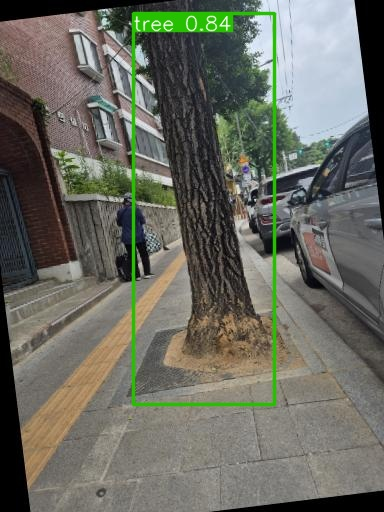

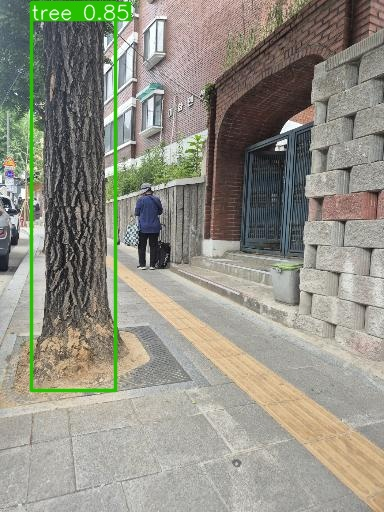

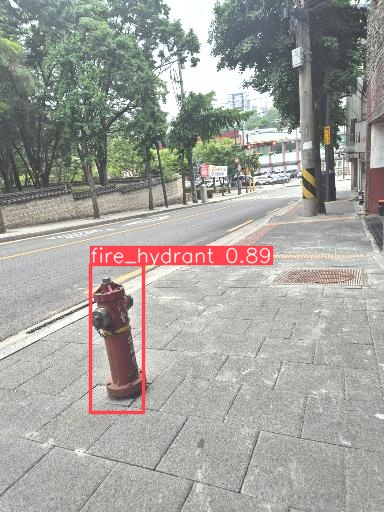

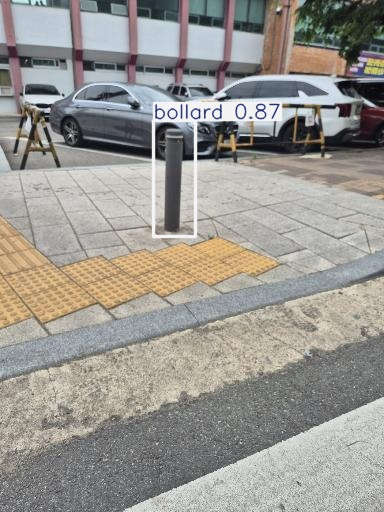

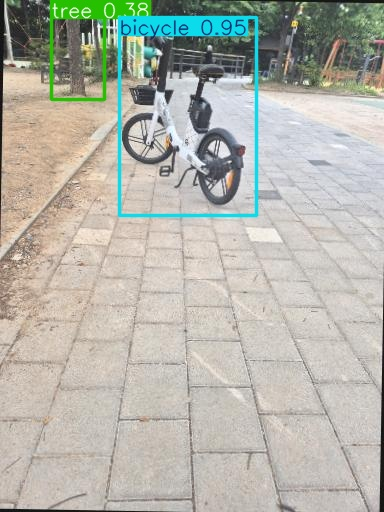

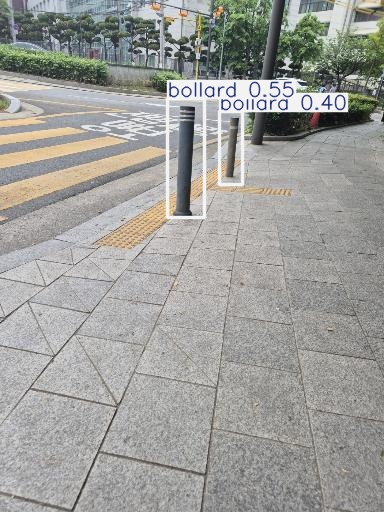

In [ ]:
import glob
from IPython.display import Image, display

pred_imgs = glob.glob("/content/runs/detect/predict/*.jpg")[:6]
for img in pred_imgs:
    display(Image(img, width=512))

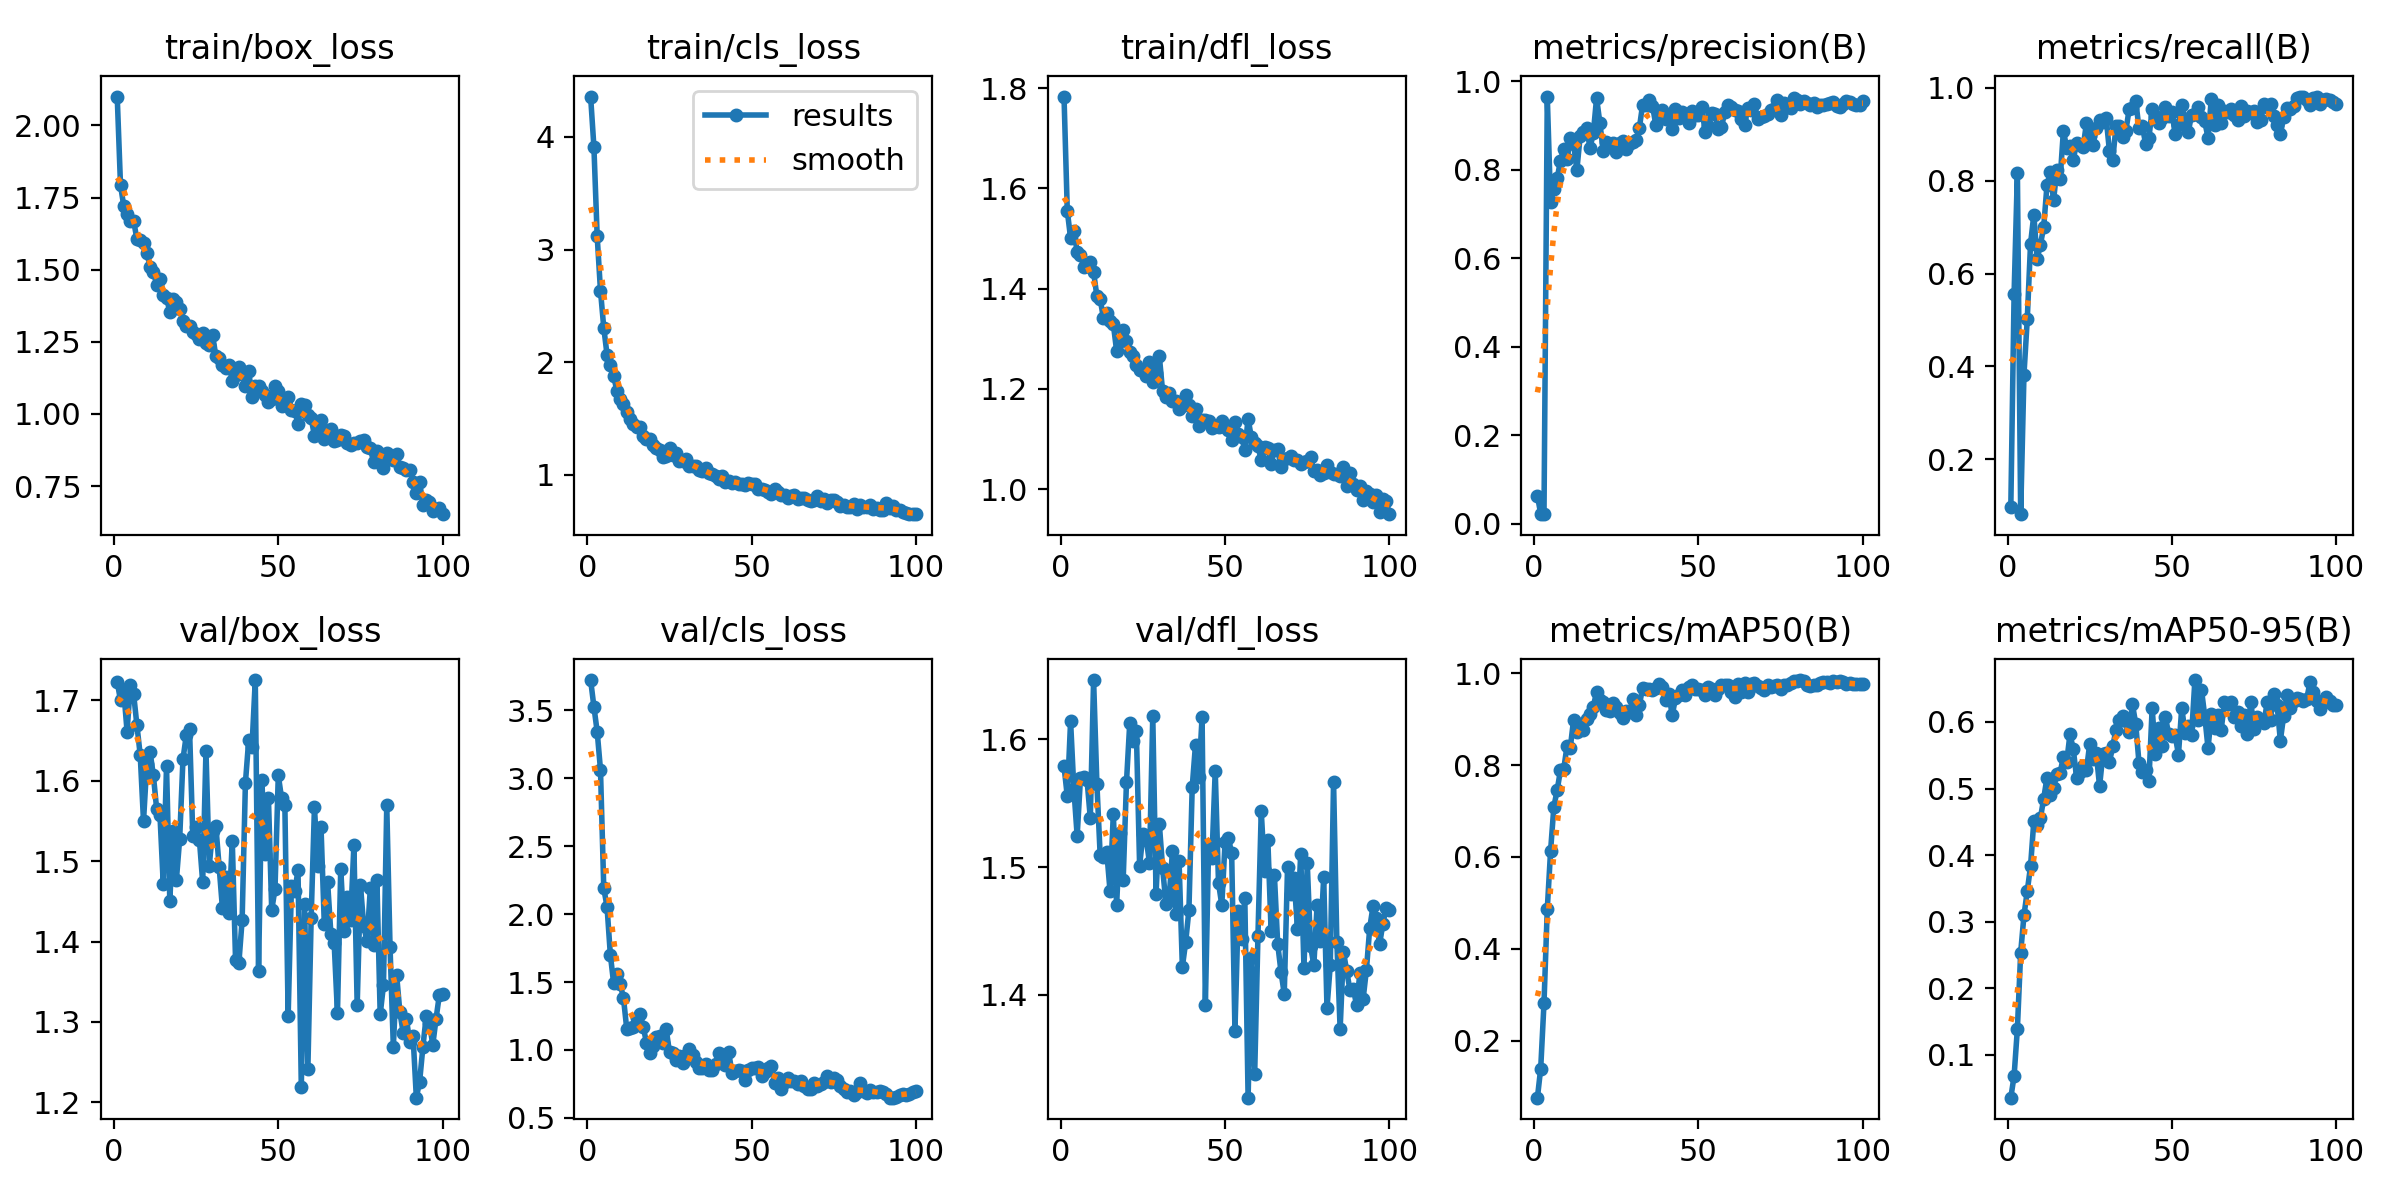

In [ ]:
from IPython.display import Image
Image("/content/runs/detect/runs/detect/noongil_v2/results.png", width=900)

## 취약 클래스 개선

In [ ]:
base = "/content/NoonGil-BarrierFree-AI-1"

### 기존 데이터셋 다운로드 진행

In [ ]:
from roboflow import Roboflow
import os, shutil, random, yaml

# NoonGil 재다운로드
rf = Roboflow(api_key="vgvnQD3ktPGMXOXsiCG7")
project = rf.workspace("s-workspace-6sd3n").project("noongil-barrierfree-ai")
version = project.version(1)
dataset = version.download("yolov8")

base = dataset.location
print(base)

# train/val/test 분할
train_img = f"{base}/train/images"
train_lbl = f"{base}/train/labels"
val_img   = f"{base}/valid/images"
val_lbl   = f"{base}/valid/labels"
test_img  = f"{base}/test/images"
test_lbl  = f"{base}/test/labels"

for d in [val_img, val_lbl, test_img, test_lbl]:
    os.makedirs(d, exist_ok=True)

imgs = [f for f in os.listdir(train_img) if f.endswith(('.jpg','.png'))]
random.seed(42)
random.shuffle(imgs)
n = len(imgs)
val_imgs  = imgs[int(n*0.7):int(n*0.9)]
test_imgs = imgs[int(n*0.9):]

def move_split(file_list, src_img, src_lbl, dst_img, dst_lbl):
    for fname in file_list:
        shutil.move(f"{src_img}/{fname}", f"{dst_img}/{fname}")
        lbl = fname.rsplit('.', 1)[0] + '.txt'
        if os.path.exists(f"{src_lbl}/{lbl}"):
            shutil.move(f"{src_lbl}/{lbl}", f"{dst_lbl}/{lbl}")

move_split(val_imgs,  train_img, train_lbl, val_img, val_lbl)
move_split(test_imgs, train_img, train_lbl, test_img, test_lbl)

print(f"train: {len(os.listdir(train_img))}, val: {len(os.listdir(val_img))}, test: {len(os.listdir(test_img))}")

loading Roboflow workspace...
loading Roboflow project...
/content/NoonGil-BarrierFree-AI-1
train: 207, val: 240, test: 122


### data.yaml 수정

In [ ]:
yaml_path = f"{base}/data.yaml"
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = train_img
data['val']   = val_img
data['test']  = test_img

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, allow_unicode=True)

print("data.yaml 수정 완료")

data.yaml 수정 완료


데이터셋 버전 확인

In [ ]:
from roboflow import Roboflow
import os

rf = Roboflow(api_key="vgvnQD3ktPGMXOXsiCG7")
project = rf.workspace("yeeun-kim-fyvoj").project("pothole-vhmow")

for v in project.versions():
    print(v.version)

loading Roboflow workspace...
loading Roboflow project...
18
17
16
15
14
9
8
7
6
5
4
3
2


### 클래스 재매핑

In [ ]:
# 확인된 버전 번호로 수정
version = project.version(18)
pothole_dataset = version.download("yolov8")
pothole_base = pothole_dataset.location

def remap_labels(label_dir, src_id=0, dst_id=8):
    if not os.path.exists(label_dir):
        print(f"스킵: {label_dir} 없음")
        return
    for fname in os.listdir(label_dir):
        if not fname.endswith('.txt'):
            continue
        path = os.path.join(label_dir, fname)
        with open(path, 'r') as f:
            lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if parts[0] == str(src_id):
                parts[0] = str(dst_id)
            new_lines.append(' '.join(parts) + '\n')
        with open(path, 'w') as f:
            f.writelines(new_lines)

remap_labels(f"{pothole_base}/train/labels")
remap_labels(f"{pothole_base}/valid/labels")
print("재매핑 완료")

스킵: /content/pothole-18/valid/labels 없음
재매핑 완료


### 샘플링

In [ ]:
import os, shutil, random

random.seed(42)

src_img = f"{pothole_base}/train/images"
src_lbl = f"{pothole_base}/train/labels"

all_imgs = [f for f in os.listdir(src_img) if f.endswith(('.jpg', '.png'))]

# 기존 최대 클래스(tree: 144)에 맞춰 150장만 샘플링
sampled = random.sample(all_imgs, 150)

dst_img = f"{base}/train/images"
dst_lbl = f"{base}/train/labels"

for fname in sampled:
    shutil.copy(f"{src_img}/{fname}", f"{dst_img}/{fname}")
    lbl = fname.rsplit('.', 1)[0] + '.txt'
    if os.path.exists(f"{src_lbl}/{lbl}"):
        shutil.copy(f"{src_lbl}/{lbl}", f"{dst_lbl}/{lbl}")

print(f"샘플링 완료: {len(sampled)}장")

샘플링 완료: 150장


### 데이터셋 병합

In [ ]:
import shutil, os

base = "/content/NoonGil-BarrierFree-AI-1"

# train만 병합 (pothole은 train 폴더만 존재)
for dtype in ['images', 'labels']:
    src = f"{pothole_base}/train/{dtype}"
    dst = f"{base}/train/{dtype}"
    os.makedirs(dst, exist_ok=True)
    for f in os.listdir(src):
        shutil.copy(f"{src}/{f}", f"{dst}/{f}")

print("병합 완료")
print(f"train 이미지 수: {len(os.listdir(base+'/train/images'))}")
print(f"val 이미지 수: {len(os.listdir(base+'/valid/images'))}")

병합 완료
train 이미지 수: 1426
val 이미지 수: 240


### 학습 진행

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data=f"{base}/data.yaml",
    epochs=100,
    imgsz=512,
    batch=16,
    name="noongil_v3",  # 버전 올리기
    project="runs/detect",
    device=0,
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/NoonGil-BarrierFree-AI-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=noongil_v3-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

### 학습 후 평가

In [ ]:
# Validation (mAP 확인)
metrics = model.val()
print(f"mAP@50:    {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")

# test 추론
results = model.predict(
    source=test_img,
    conf=0.25,
    save=True
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1454.8±565.0 MB/s, size: 42.8 KB)
val: Scanning /content/NoonGil-BarrierFree-AI-1/valid/labels.cache... 240 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 240/240 71.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 4.5it/s 3.4s
                   all        240        400      0.901      0.911      0.927       0.59
                 bench         10         22       0.84      0.951      0.936      0.597
               bicycle         52         58      0.904      0.966      0.989      0.617
               bollard         28         45      0.977      0.936       0.99       0.51
          clothing_bin          6          6      0.882          1      0.995      0.717
                  cone         

In [ ]:
import glob

# 저장된 모든 best.pt 경로 찾기
weights = glob.glob("/content/runs/detect/**/weights/best.pt", recursive=True)
for w in weights:
    print(w)

/content/runs/detect/runs/detect/noongil_v3-3/weights/best.pt
/content/runs/detect/runs/detect/noongil_v3-2/weights/best.pt


In [ ]:
import shutil, os

os.makedirs("/content/drive/MyDrive/NoonGil/weights", exist_ok=True)

shutil.copy(
    "/content/runs/detect/runs/detect/noongil_v3-3/weights/best.pt",
    "/content/drive/MyDrive/NoonGil/weights/noongil_v3_best.pt"
)
print("백업 완료!")

백업 완료!


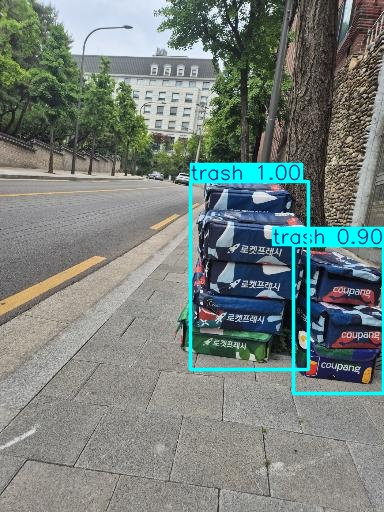

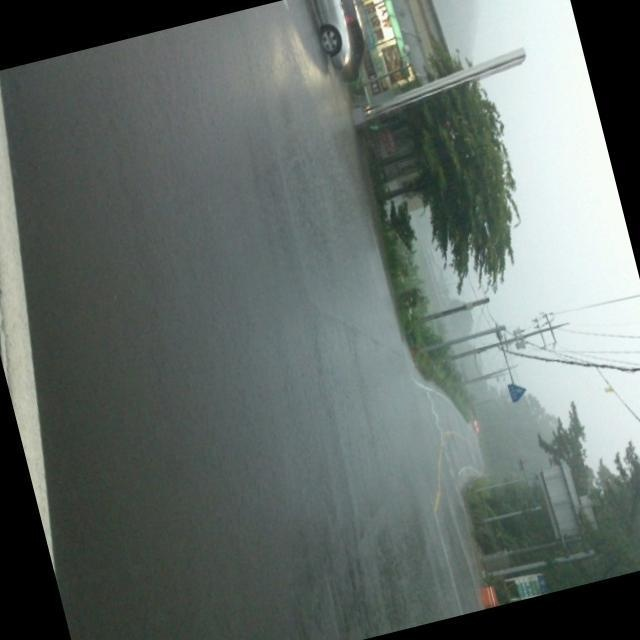

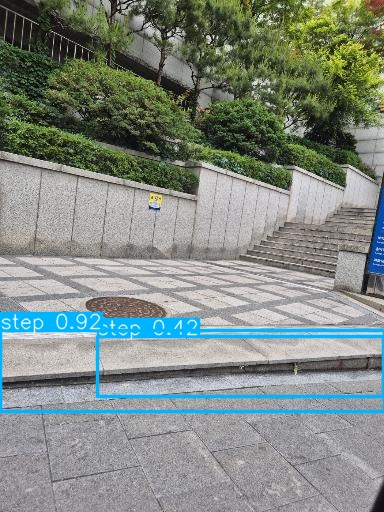

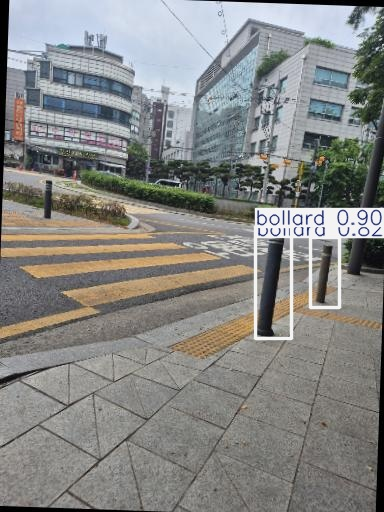

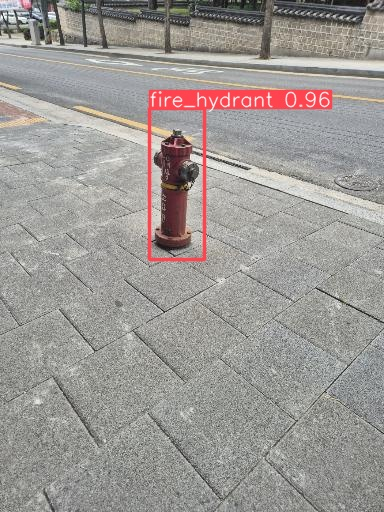

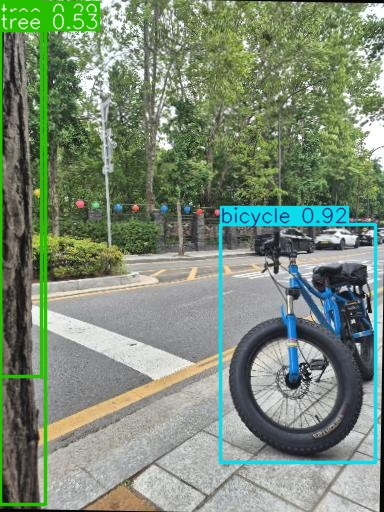

In [ ]:
import glob
from IPython.display import Image, display

pred_imgs = glob.glob("/content/runs/detect/predict/*.jpg")[:6]
for img in pred_imgs:
    display(Image(img, width=512))

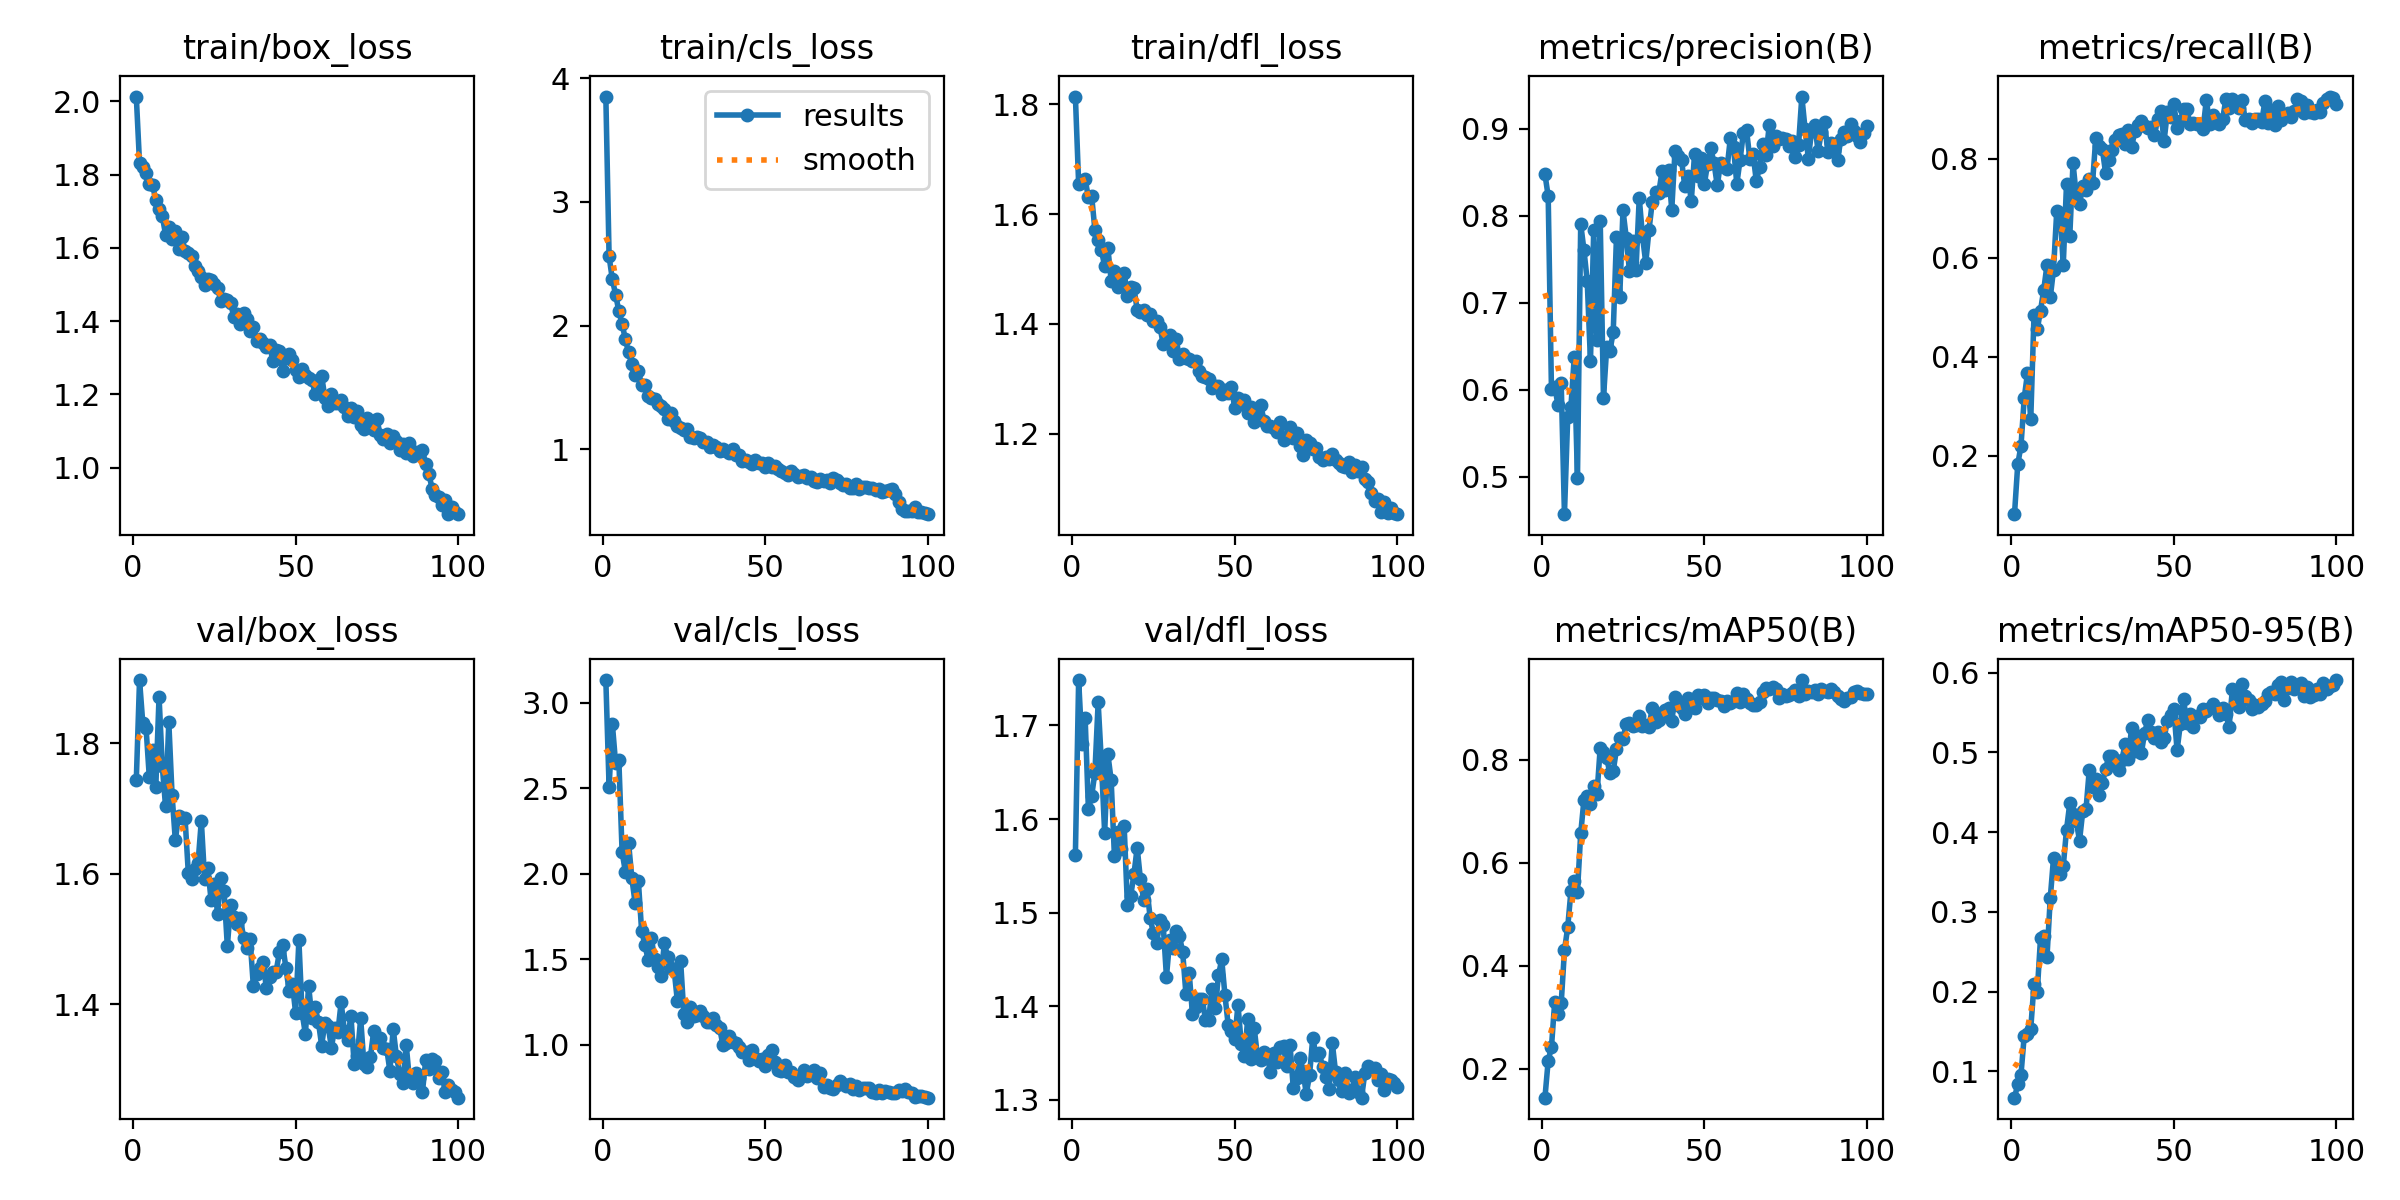

In [ ]:
from IPython.display import Image
Image("/content/runs/detect/runs/detect/noongil_v3-3/results.png", width=900)

## 취약 클래스 개선 2

### NoonGil 재다운로드 + 분할 + data.yaml 수정

In [3]:
from roboflow import Roboflow
import os, shutil, random, yaml

rf = Roboflow(api_key="vgvnQD3ktPGMXOXsiCG7")
dataset = rf.workspace("s-workspace-6sd3n").project("noongil-barrierfree-ai").version(1).download("yolov8")
base = dataset.location

train_img = f"{base}/train/images"; train_lbl = f"{base}/train/labels"
val_img   = f"{base}/valid/images"; val_lbl   = f"{base}/valid/labels"
test_img  = f"{base}/test/images";  test_lbl  = f"{base}/test/labels"

for d in [val_img, val_lbl, test_img, test_lbl]:
    os.makedirs(d, exist_ok=True)

imgs = [f for f in os.listdir(train_img) if f.endswith(('.jpg','.png'))]
random.seed(42); random.shuffle(imgs); n = len(imgs)
val_imgs  = imgs[int(n*0.7):int(n*0.9)]
test_imgs = imgs[int(n*0.9):]

def move_split(file_list, si, sl, di, dl):
    for fname in file_list:
        shutil.move(f"{si}/{fname}", f"{di}/{fname}")
        lbl = fname.rsplit('.', 1)[0] + '.txt'
        if os.path.exists(f"{sl}/{lbl}"): shutil.move(f"{sl}/{lbl}", f"{dl}/{lbl}")

move_split(val_imgs,  train_img, train_lbl, val_img, val_lbl)
move_split(test_imgs, train_img, train_lbl, test_img, test_lbl)
print(f"train: {len(os.listdir(train_img))}, val: {len(os.listdir(val_img))}, test: {len(os.listdir(test_img))}")

yaml_path = f"{base}/data.yaml"
with open(yaml_path, 'r') as f: data = yaml.safe_load(f)
data['train'] = train_img; data['val'] = val_img; data['test'] = test_img
with open(yaml_path, 'w') as f: yaml.dump(data, f, allow_unicode=True)
print("data.yaml 수정 완료")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to NoonGil-BarrierFree-AI-1 in yolov8:: 100%|██████████| 777/777 [00:00<00:00, 6225.18it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
train: 270, val: 78, test: 39
data.yaml 수정 완료


### 공통 함수 정의

In [4]:
def remap_labels(label_dir, src_id, dst_id):
    if not os.path.exists(label_dir):
        print(f"스킵: {label_dir} 없음"); return
    for fname in os.listdir(label_dir):
        if not fname.endswith('.txt'): continue
        path = os.path.join(label_dir, fname)
        with open(path, 'r') as f: lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if parts[0] == str(src_id): parts[0] = str(dst_id)
            new_lines.append(' '.join(parts) + '\n')
        with open(path, 'w') as f: f.writelines(new_lines)

def sample_and_merge(src_base, dst_base, n=150, splits=['train']):
    for split in splits:
        src_img = f"{src_base}/{split}/images"
        src_lbl = f"{src_base}/{split}/labels"
        dst_img = f"{dst_base}/{split}/images"
        dst_lbl = f"{dst_base}/{split}/labels"
        if not os.path.exists(src_img): print(f"스킵: {src_img}"); continue
        imgs = [f for f in os.listdir(src_img) if f.endswith(('.jpg','.png'))]
        sampled = random.sample(imgs, min(n, len(imgs)))
        for fname in sampled:
            shutil.copy(f"{src_img}/{fname}", f"{dst_img}/{fname}")
            lbl = fname.rsplit('.', 1)[0] + '.txt'
            if os.path.exists(f"{src_lbl}/{lbl}"):
                shutil.copy(f"{src_lbl}/{lbl}", f"{dst_lbl}/{lbl}")
        print(f"{split} {len(sampled)}장 병합 완료")

### pothole 다운로드 + 재매핑 + 병합 (pavement_damage: 8)

In [5]:
rf2 = Roboflow(api_key="vgvnQD3ktPGMXOXsiCG7")
pothole_dataset = rf2.workspace("yeeun-kim-fyvoj").project("pothole-vhmow").version(18).download("yolov8")
pothole_base = pothole_dataset.location

remap_labels(f"{pothole_base}/train/labels", src_id=0, dst_id=8)
remap_labels(f"{pothole_base}/valid/labels", src_id=0, dst_id=8)
sample_and_merge(pothole_base, base, n=150)
print(f"병합 후 train: {len(os.listdir(train_img))}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pothole-18 in yolov8:: 100%|██████████| 2610/2610 [00:00<00:00, 6951.50it/s]


스킵: /content/pothole-18/valid/labels 없음
train 150장 병합 완료
병합 후 train: 420


### curb 다운로드 + 재매핑 + 병합 (step: 10)

In [6]:
curb_dataset = rf2.workspace("vspace").project("curb-xtrmz").version(1).download("yolov8")
curb_base = curb_dataset.location

# 버전 확인 필요 시
# for v in rf2.workspace("vspace").project("curb-xtrmz").versions(): print(v.version)

remap_labels(f"{curb_base}/train/labels", src_id=0, dst_id=10)
remap_labels(f"{curb_base}/valid/labels", src_id=0, dst_id=10)
sample_and_merge(curb_base, base, n=150)
print(f"병합 후 train: {len(os.listdir(train_img))}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to curb-1 in yolov8:: 100%|██████████| 2520/2520 [00:00<00:00, 5708.22it/s]


train 150장 병합 완료
병합 후 train: 570


### ramp 다운로드 + 재매핑 + 병합 (ramp:9, stairs:10)

In [7]:
# ramp 데이터셋 다운로드
ramp_dataset = rf2.workspace("nan-gl4fb").project("ramp-udoeh").version(1).download("yolov8")
ramp_base = ramp_dataset.location

# 클래스 ID 확인 (ramp=0, stairs=1 인지 확인)
import yaml
with open(f"{ramp_base}/data.yaml", 'r') as f:
    ramp_yaml = yaml.safe_load(f)
print(ramp_yaml['names'])  # 순서 확인 필수!

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ramp-1 in yolov8:: 100%|██████████| 236/236 [00:00<00:00, 4450.33it/s]

['ramp', 'stairs']


In [8]:
# ramp → 9, stairs → 10 으로 각각 재매핑
def remap_labels_multi(label_dir, mapping):
    """mapping: {src_id: dst_id} 딕셔너리"""
    if not os.path.exists(label_dir):
        print(f"스킵: {label_dir} 없음"); return
    for fname in os.listdir(label_dir):
        if not fname.endswith('.txt'): continue
        path = os.path.join(label_dir, fname)
        with open(path, 'r') as f: lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if parts[0] in [str(k) for k in mapping]:
                parts[0] = str(mapping[int(parts[0])])
            new_lines.append(' '.join(parts) + '\n')
        with open(path, 'w') as f: f.writelines(new_lines)

# ramp=0→9, stairs=1→10
mapping = {0: 9, 1: 10}
remap_labels_multi(f"{ramp_base}/train/labels", mapping)
remap_labels_multi(f"{ramp_base}/valid/labels", mapping)
print("재매핑 완료")

# 112장 전부 병합 (샘플링 없이)
sample_and_merge(ramp_base, base, n=200)  # 전체 사용
print(f"ramp 병합 후 train: {len(os.listdir(train_img))}")

재매핑 완료
train 74장 병합 완료
ramp 병합 후 train: 644


### 재학습

In [9]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=512,
    batch=16,
    name="noongil_v4",  # 버전 올리기
    project="runs/detect",
    device=0,
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/NoonGil-BarrierFree-AI-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=noongil_v4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

### 평가 + 백업

In [13]:
import glob

metrics = model.val()
print(f"mAP@50:    {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")

weights = glob.glob("/content/runs/detect/**/weights/best.pt", recursive=True)
for w in weights: print(w)

# 가장 최신 경로로 백업
import shutil, os

os.makedirs("/content/drive/MyDrive/NoonGil/weights", exist_ok=True)

shutil.copy(
    "/content/runs/detect/runs/detect/noongil_v4/weights/best.pt",
    "/content/drive/MyDrive/NoonGil/weights/noongil_v4_best.pt"
)
print("백업 완료!")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1963.3±505.4 MB/s, size: 44.6 KB)
val: Scanning /content/NoonGil-BarrierFree-AI-1/valid/labels.cache... 78 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 78/78 32.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.6it/s 1.9s
                   all         78        137      0.899      0.938      0.979       0.68
                 bench          5         12      0.816      0.833      0.903      0.526
               bicycle         16         18      0.941          1      0.995      0.688
               bollard         13         17      0.969          1      0.995      0.635
          clothing_bin          3          3      0.731          1      0.995      0.863
                  cone          4          6          1      0.756      0.995       0.51
      electric_scooter      

In [15]:
import glob
from IPython.display import Image, display

pred_imgs = glob.glob("/content/runs/detect/predict/*.jpg")[:6]
for img in pred_imgs:
    display(Image(img, width=512))

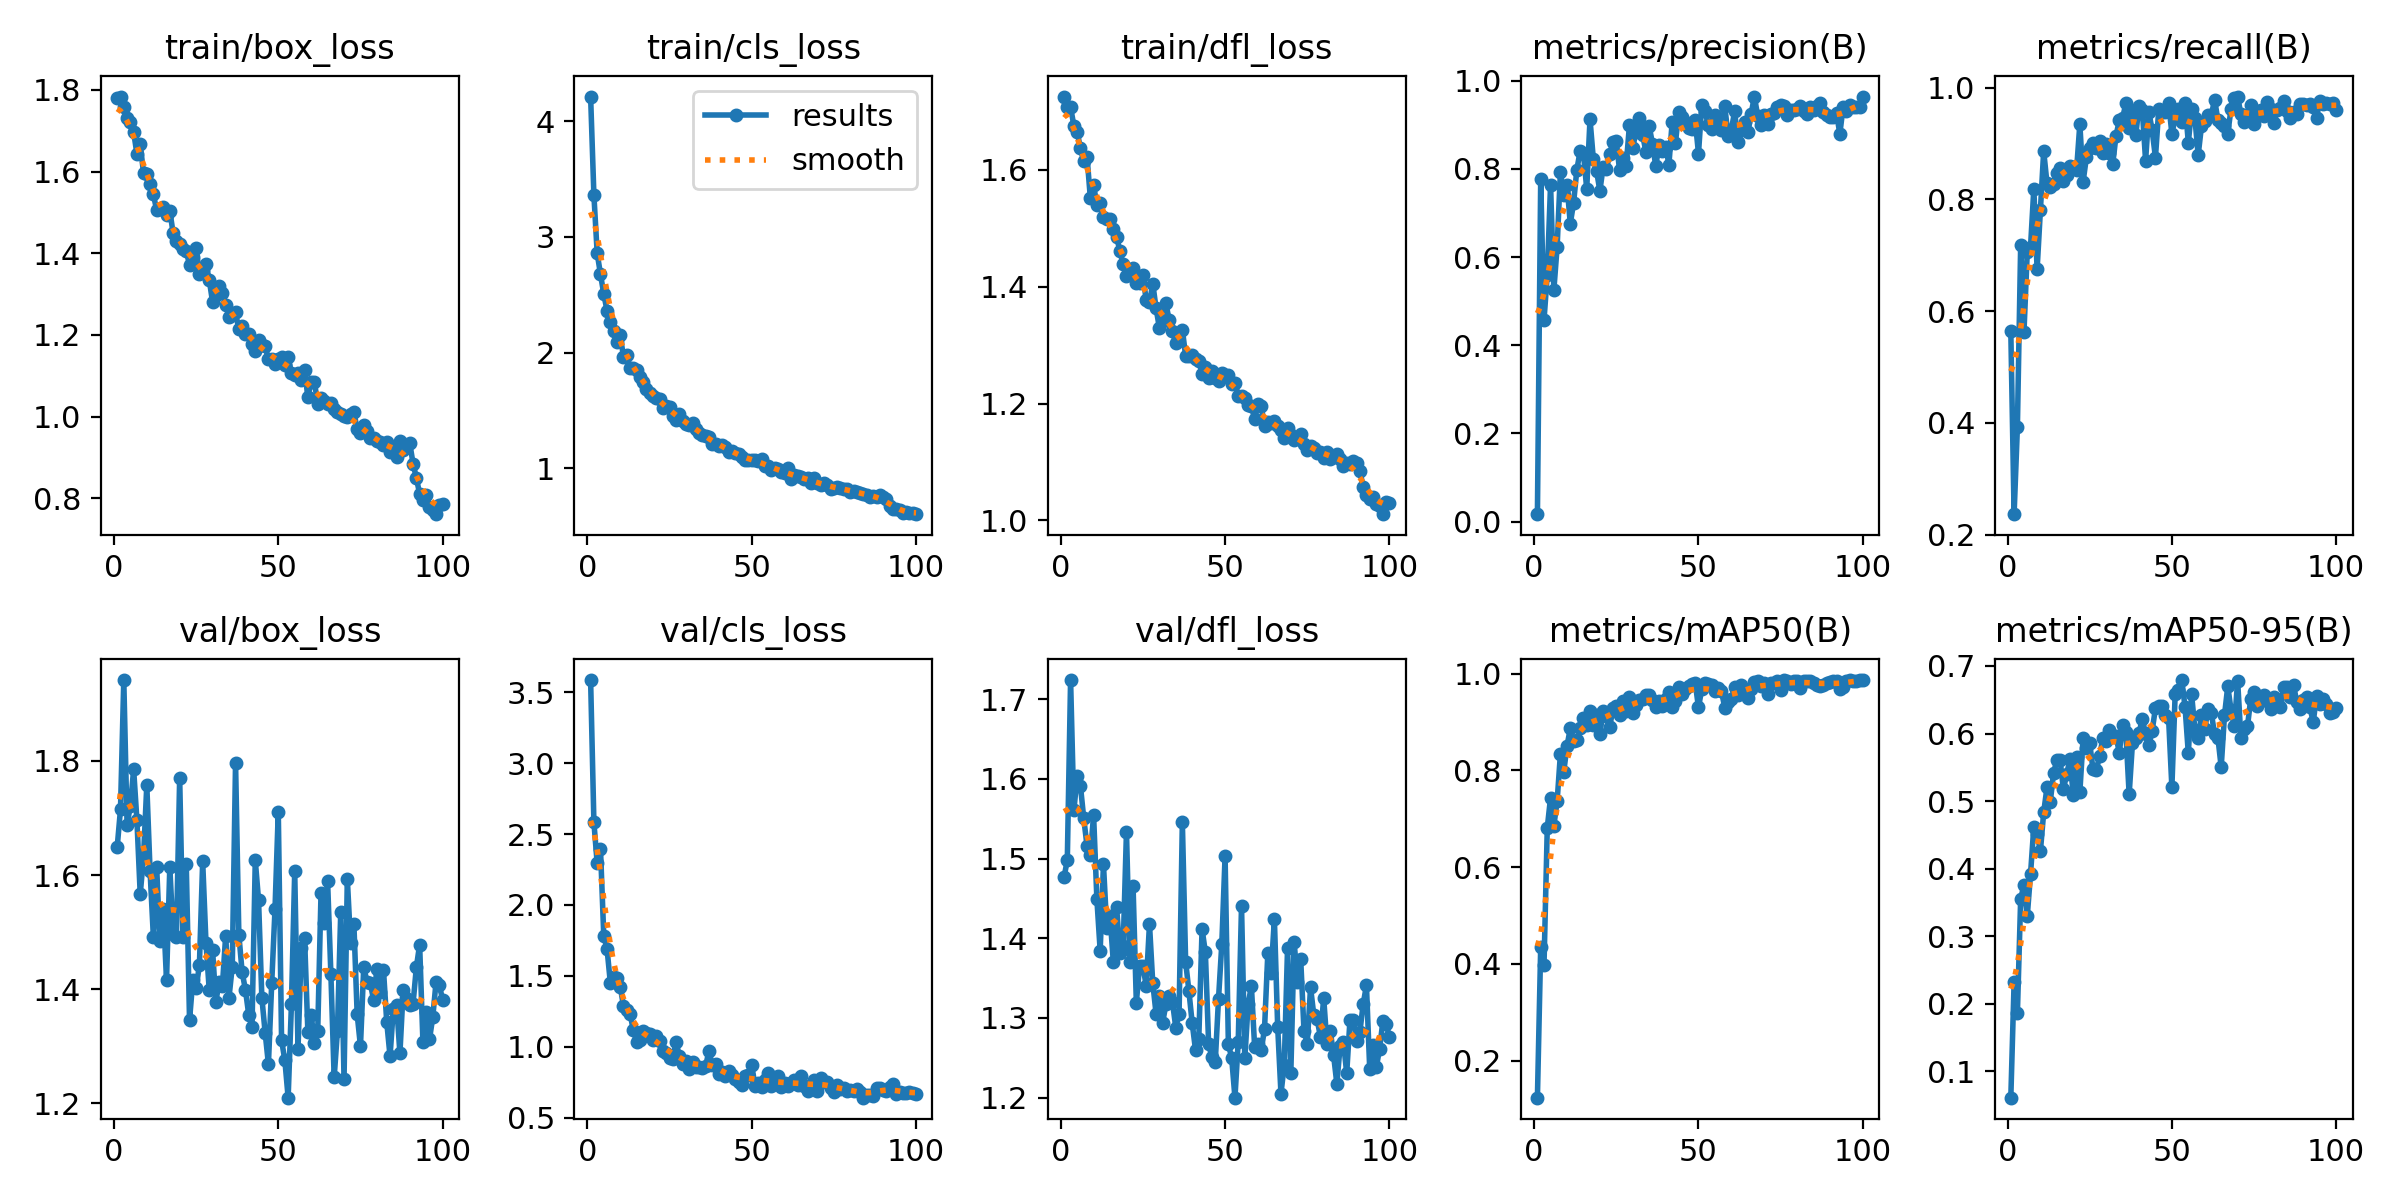

In [17]:
from IPython.display import Image
Image("/content/runs/detect/runs/detect/noongil_v4/results.png", width=900)